pygame 2.6.1 (SDL 2.28.4, Python 3.13.2)
Hello from the pygame community. https://www.pygame.org/contribute.html
[[600 700]]
[[600 700]]
[[600 700]]
[[600 700]]
[[632.45553203   0.        ]
 [  0.         721.11025509]]
[[447.2135955   0.       ]
 [  0.        471.6990566]]


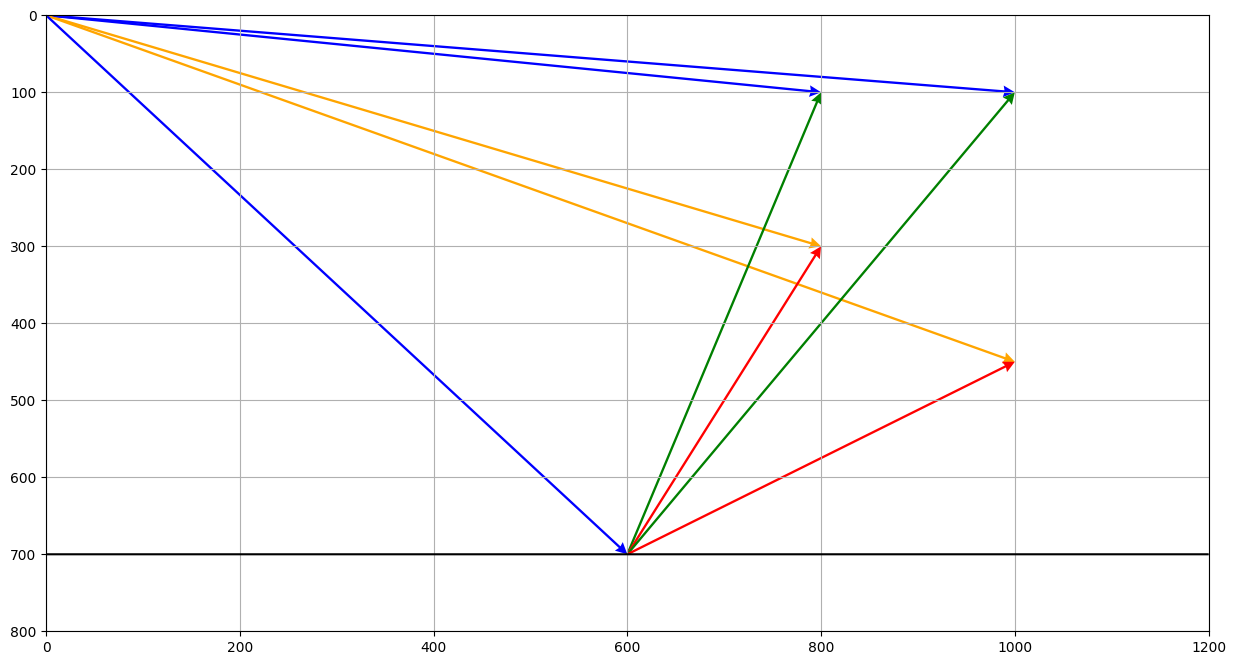

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from space_marauders.game_management.linear_algebra import DifferenceMatrix, DistanceMatrix, PositionMatrix


# Define the starting point (origin) and the vector components
origin = np.array([[0, 0], [0, 0]])
vectors = np.array([[200, 30], [500, 200]])

alien_positions = PositionMatrix([
    [800, 100],
    [1000, 100]
])
bomb_positions = PositionMatrix([
    [800, 300],
    [1000, 450]
])
origin = np.zeros((alien_positions.shape[0], 2))

plt.figure(figsize=(15, 8))
for i in range(alien_positions.shape[0]):
    plt.quiver(
        *origin[i].reshape(2, 1),
        alien_positions[i, 0],
        alien_positions[i, 1],
        angles='xy',
        scale_units='xy',
        scale=1,
        color='blue',
        label=f'alien_{i}',
        width=0.002,
        headwidth=5
    )
    plt.quiver(
        *origin[i].reshape(2, 1),
        bomb_positions[i, 0],
        bomb_positions[i, 1],
        angles='xy',
        scale_units='xy',
        scale=1,
        color='orange',
        label=f'bomb_{i}',
        width=0.002,
        headwidth=5
    )

player_position = PositionMatrix([[600, 700]])
plt.quiver(*np.zeros((2, 1)), player_position[0, 0], player_position[0, 1], angles='xy', scale_units='xy', scale=1, color='blue', label='player', width=0.002, headwidth=5)

difference_player_to_aliens = DifferenceMatrix(alien_positions, player_position.row_stack(player_position))
difference_player_to_bombs = DifferenceMatrix(bomb_positions, player_position.row_stack(player_position))

for i in range(difference_player_to_aliens.shape[0]):
    plt.quiver(
        *player_position.reshape((2, 1)),
        difference_player_to_aliens[i, 0],
        difference_player_to_aliens[i, 1],
        angles='xy',
        scale_units='xy',
        scale=1,
        color='green',
        label=f'to_alien_{i}',
        width=0.002,
        headwidth=5
    )
    plt.quiver(
        *player_position.reshape((2, 1)),
        difference_player_to_bombs[i, 0],
        difference_player_to_bombs[i, 1],
        angles='xy',
        scale_units='xy',
        scale=1,
        color='red',
        label=f'to_bomb_{i}',
        width=0.002,
        headwidth=5
    )

plt.plot([700] * 1200, color='black')

player_distance_from_aliens = DistanceMatrix(difference_player_to_aliens)
player_distance_from_bombs = DistanceMatrix(difference_player_to_bombs)
I = np.identity(2)
print(player_distance_from_aliens.get_distances() * I)
print(player_distance_from_bombs.get_distances() * I)

plt.gca().invert_yaxis()

screen_width = 1200
screen_height = 800
plt.xlim(0, screen_width)
plt.ylim(screen_height, 0)

plt.grid()
plt.show()

In [2]:
from space_marauders.game_management.linear_algebra import DifferenceMatrix, DistanceMatrix, PositionMatrix

data_a = [
    [3, 3],
    [3, 3]
]
data_b = [
    [2, 1],
    [3, 2]
]

A = PositionMatrix(data_a)
B = PositionMatrix(data_b)
C = DifferenceMatrix(A, B)

C

[[1 2]
 [0 1]]

In [3]:
C.transpose()

[[1 0]
 [2 1]]

In [4]:
C.column_mapping

{'column_0': 0, 'column_1': 1}

In [5]:
C.row_mapping

{'row_0': 0, 'row_1': 1}

In [6]:
D = DistanceMatrix(C)
D
# D.get_distances()

[[2.23606798 1.41421356]
 [1.41421356 1.        ]]

In [7]:
import numpy as np

D.get_distances()

array([[2.23606798],
       [1.        ]])

In [8]:
A.add_row_vector([2, 4])

[[3 3]
 [3 3]]
[[2 4]]


In [9]:
A.add_row_vector([5, 7])

[[3 3]
 [3 3]
 [2 4]]
[[5 7]]
